# 9. Classification — LSTM (Long Short-Term Memory)

**Scratch**: Full LSTM cell (4 gates) + Adam optimiser, pure NumPy  
**PyTorch**: `nn.LSTM → nn.Linear`, same hyperparameters

### Theory

A standard LSTM cell processes one timestep $x_t$ and the previous hidden state $h_{t-1}$, maintaining a **cell state** $c_t$ that carries long-range information.

**Four gates** (all share input $[h_{t-1},\, x_t]$):

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \qquad \text{forget gate — what to erase from } c_{t-1}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \qquad \text{input gate — how much new info to write}$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c) \qquad \text{cell candidate — new info to potentially write}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \qquad \text{output gate — what to expose as hidden state}$$

**State updates**:
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

After processing all 24 timesteps, $h_{24}$ is passed through a **Linear + Sigmoid** layer to produce the Up/Down probability.

**Why LSTM beats vanilla RNN**: The cell state $c_t$ provides a gradient highway — the forget gate $f_t$ can stay near 1.0, allowing gradients to flow back through many timesteps without vanishing.


In [1]:
!pip install torch --quiet

In [ ]:
import os, json, pickle, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(BASE_DIR, 'data')
MODELS_DIR   = os.path.join(BASE_DIR, 'models')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
FIGURES_DIR  = os.path.join(BASE_DIR, 'figures')

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

RESULTS_CSV  = os.path.join(RESULTS_DIR, 'classification_results.csv')
FEATURES_JSON = os.path.join(DATA_DIR, 'selected_features_classification.json')

# ── Shared Utilities ───────────────────────────────────────────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    """Return a dict of all evaluation metrics matching the project results CSV."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = (cm.ravel() if cm.size == 4
                      else (0, 0, int((y_true == 0).sum()), int((y_true == 1).sum())))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # = recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # = TNR

    metrics = {
        'model':       model_name,
        'accuracy':    accuracy_score(y_true, y_pred),
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tnr':         specificity,
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':     roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        'tp':          float(tp),
        'tn':          float(tn),
        'fp':          float(fp),
        'fn':          float(fn),
        'recall':      sensitivity,
    }
    return metrics

def save_results(metrics_dict):
    """Append (or replace) one row in the shared classification_results.csv."""
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        df = pd.read_csv(RESULTS_CSV)
        df = df[df['model'] != metrics_dict['model']]
        df = pd.concat([df, row], ignore_index=True)
    else:
        df = row
    df.to_csv(RESULTS_CSV, index=False)
    print(f"  ✔ Results saved → {RESULTS_CSV}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    """Plot and save a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"  ✔ Figure saved → {save_path}")

print("Imports ready. PyTorch:", torch.__version__)
print("BASE_DIR:", BASE_DIR)


Imports ready. PyTorch: 2.10.0
BASE_DIR: /Users/mihiniboteju/cryptoflow


In [5]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW      = 24      # lookback timesteps
HIDDEN      = 64      # LSTM hidden units
N_LAYERS    = 1
EPOCHS      = 50
PATIENCE    = 10      # early stopping patience on val loss
BATCH_SIZE  = 64
LR          = 0.001
VAL_FRAC    = 0.10    # last 10% of windowed train sequences → validation

# ── Load data ──────────────────────────────────────────────────────────────────
with open(FEATURES_JSON) as f:
    FEATURES = json.load(f)
print("Features:", FEATURES)

df_train = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))

X_raw_train = df_train[FEATURES].values.astype(np.float32)
y_raw_train = df_train['target_class'].values.astype(np.int64)
X_raw_test  = df_test[FEATURES].values.astype(np.float32)
y_raw_test  = df_test['target_class'].values.astype(np.int64)

print(f"Train rows: {len(X_raw_train):,}  |  Test rows: {len(X_raw_test):,}")

# ── Fit fresh scaler on train only ─────────────────────────────────────────────
scaler = StandardScaler()
X_sc_train = scaler.fit_transform(X_raw_train)
X_sc_test  = scaler.transform(X_raw_test)

scaler_path = os.path.join(MODELS_DIR, 'scaler_lstm.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✔ Scaler saved → {scaler_path}")

# ── Build sliding windows ──────────────────────────────────────────────────────
def make_windows(X, y, window):
    """Return (X_win, y_win) where X_win[i] = X[i : i+window], y_win[i] = y[i+window]."""
    n = len(X) - window
    X_win = np.stack([X[i:i+window] for i in range(n)], axis=0)
    y_win = y[window:]
    return X_win, y_win

X_win_train, y_win_train = make_windows(X_sc_train, y_raw_train, WINDOW)
X_win_test,  y_win_test  = make_windows(X_sc_test,  y_raw_test,  WINDOW)

# ── Temporal validation split (last 10% of windowed train) ────────────────────
n_val = int(len(X_win_train) * VAL_FRAC)
n_tr  = len(X_win_train) - n_val

X_tr,  X_val  = X_win_train[:n_tr],  X_win_train[n_tr:]
y_tr,  y_val  = y_win_train[:n_tr],  y_win_train[n_tr:]

print(f"\nWindowed shapes:")
print(f"  X_tr   : {X_tr.shape}   y_tr   : {y_tr.shape}")
print(f"  X_val  : {X_val.shape}   y_val  : {y_val.shape}")
print(f"  X_test : {X_win_test.shape}  y_test : {y_win_test.shape}")

Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']
Train rows: 60,260  |  Test rows: 10,635
  ✔ Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_lstm.pkl

Windowed shapes:
  X_tr   : (54213, 24, 10)   y_tr   : (54213,)
  X_val  : (6023, 24, 10)   y_val  : (6023,)
  X_test : (10611, 24, 10)  y_test : (10611,)


## Part 1 — Scratch LSTM (NumPy + Adam)

Full gate computations and BPTT implemented by hand. The four weight matrices are stacked as a single $(4H) \times (H+D)$ matrix for efficiency, then sliced per gate during the forward pass.

In [6]:
class LSTMScratch:
    """
    Single-layer LSTM with BCE loss, Adam optimiser, and early stopping.
    Weights are stored as a stacked (4H × (H+D)) matrix to match standard
    reference implementations; sliced per gate during the forward pass.
    """

    def __init__(self, input_dim, hidden_dim, lr=0.001,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        self.D = input_dim
        self.H = hidden_dim
        self.lr = lr
        self.b1 = beta1
        self.b2 = beta2
        self.eps = eps

        # Xavier init for recurrent weights
        scale_W = np.sqrt(2.0 / (input_dim + hidden_dim))
        scale_U = np.sqrt(2.0 / (hidden_dim + hidden_dim))

        # Stacked weight matrices  [4H × D]  [4H × H]  [4H] bias
        self.Wx = np.random.randn(4 * hidden_dim, input_dim)  * scale_W
        self.Wh = np.random.randn(4 * hidden_dim, hidden_dim) * scale_U
        self.b  = np.zeros(4 * hidden_dim)

        # Output layer
        self.Wy = np.random.randn(hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.by = np.array([0.0])

        # Adam moment buffers
        params = ['Wx','Wh','b','Wy','by']
        self._m = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._t = 0

    # ── Activations ──────────────────────────────────────────────────────────
    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    # ── Forward through T timesteps for a single sample ──────────────────────
    def _forward_sequence(self, x_seq):
        """
        x_seq: (T, D)
        Returns (h_list, c_list, gate_list) for use in backward pass.
        """
        T = len(x_seq)
        H = self.H
        h = np.zeros(H); c = np.zeros(H)
        hs, cs, gates = [h.copy()], [c.copy()], []

        for t in range(T):
            z = self.Wx @ x_seq[t] + self.Wh @ h + self.b   # (4H,)
            f  = self._sigmoid(z[0*H:1*H])
            i  = self._sigmoid(z[1*H:2*H])
            g  = np.tanh(z[2*H:3*H])
            o  = self._sigmoid(z[3*H:4*H])

            c  = f * cs[-1] + i * g
            h  = o * np.tanh(c)

            hs.append(h.copy())
            cs.append(c.copy())
            gates.append((f, i, g, o, z, x_seq[t]))

        return hs, cs, gates

    # ── Predict probability for a single sequence ────────────────────────────
    def _predict_one(self, x_seq):
        hs, cs, _ = self._forward_sequence(x_seq)
        h_last = hs[-1]
        logit  = self.Wy @ h_last + self.by
        return float(self._sigmoid(logit)), h_last

    # ── BPTT for one sample ──────────────────────────────────────────────────
    def _backward_one(self, x_seq, y, p):
        hs, cs, gates = self._forward_sequence(x_seq)
        T = len(x_seq); H = self.H

        # Output layer gradient
        dy = (p - y)                       # scalar, dBCE/d_logit
        dWy = dy * hs[-1]
        dby = np.array([dy])
        dh_last = dy * self.Wy             # (H,)

        # BPTT through T timesteps
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        db  = np.zeros_like(self.b)
        dh_next = dh_last.copy()
        dc_next = np.zeros(H)

        for t in reversed(range(T)):
            f, i, g, o, z, x_t = gates[t]
            c_prev = cs[t]
            c_t    = cs[t+1]

            tanh_c = np.tanh(c_t)

            dh = dh_next
            dc = dh * o * (1 - tanh_c**2) + dc_next

            df = dc * c_prev
            di = dc * g
            dg = dc * i
            do = dh * tanh_c

            # Pre-activation gradients (through activation derivatives)
            dz = np.concatenate([
                df * f * (1 - f),          # forget
                di * i * (1 - i),          # input
                dg * (1 - g**2),           # cell candidate
                do * o * (1 - o),          # output
            ])

            dWx += np.outer(dz, x_t)
            dWh += np.outer(dz, hs[t])
            db  += dz

            dc_next = dc * f
            dh_next = self.Wh.T @ dz

        return {'Wx': dWx, 'Wh': dWh, 'b': db, 'Wy': dWy, 'by': dby}

    # ── Adam update ──────────────────────────────────────────────────────────
    def _adam_step(self, grads):
        self._t += 1
        t = self._t
        for pname, grad in grads.items():
            self._m[pname] = self.b1 * self._m[pname] + (1 - self.b1) * grad
            self._v[pname] = self.b2 * self._v[pname] + (1 - self.b2) * grad**2
            m_hat = self._m[pname] / (1 - self.b1**t)
            v_hat = self._v[pname] / (1 - self.b2**t)
            param = getattr(self, pname)
            setattr(self, pname, param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))

    # ── BCE loss over a batch ────────────────────────────────────────────────
    @staticmethod
    def _bce(y_true, y_prob):
        y_prob = np.clip(y_prob, 1e-12, 1 - 1e-12)
        return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

    # ── Mini-batch SGD training loop ─────────────────────────────────────────
    def fit(self, X_tr, y_tr, X_val, y_val,
            epochs=50, batch_size=64, patience=10):
        """
        Temporal mini-batches. Early stopping on val loss.
        Returns (train_losses, val_losses).
        """
        n = len(X_tr)
        best_val = np.inf
        patience_count = 0
        best_params = None
        train_losses, val_losses = [], []

        for epoch in range(1, epochs + 1):
            t0 = time.time()
            idx = np.random.permutation(n)
            epoch_loss = 0.0

            for start in range(0, n, batch_size):
                batch_idx = idx[start:start + batch_size]
                acc_grads = {p: np.zeros_like(getattr(self, p))
                             for p in ['Wx','Wh','b','Wy','by']}
                batch_probs = []

                for j in batch_idx:
                    p, _ = self._predict_one(X_tr[j])
                    batch_probs.append(p)
                    g = self._backward_one(X_tr[j], y_tr[j], p)
                    for p_name in acc_grads:
                        acc_grads[p_name] += g[p_name]

                # Average gradients
                bs = len(batch_idx)
                for p_name in acc_grads:
                    acc_grads[p_name] /= bs
                self._adam_step(acc_grads)
                epoch_loss += self._bce(y_tr[batch_idx],
                                        np.array(batch_probs))

            epoch_loss /= max(1, n // batch_size)
            train_losses.append(epoch_loss)

            # Validation loss
            val_probs = np.array([self._predict_one(X_val[j])[0]
                                  for j in range(len(X_val))])
            val_loss  = self._bce(y_val, val_probs)
            val_losses.append(val_loss)

            elapsed = time.time() - t0
            print(f"  Epoch {epoch:>3}/{epochs}  "
                  f"train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"({elapsed:.1f}s)")

            if val_loss < best_val:
                best_val = val_loss
                patience_count = 0
                best_params = {p: getattr(self, p).copy()
                               for p in ['Wx','Wh','b','Wy','by']}
            else:
                patience_count += 1
                if patience_count >= patience:
                    print(f"  Early stopping at epoch {epoch} "
                          f"(best val_loss={best_val:.4f})")
                    break

        # Restore best weights
        if best_params:
            for p, v in best_params.items():
                setattr(self, p, v)

        return train_losses, val_losses

    # ── Inference ────────────────────────────────────────────────────────────
    def predict_proba(self, X):
        return np.array([self._predict_one(X[i])[0] for i in range(len(X))])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("LSTMScratch class defined.")

LSTMScratch class defined.


In [8]:
np.random.seed(42)
lstm_scratch = LSTMScratch(input_dim=len(FEATURES), hidden_dim=HIDDEN, lr=LR)

print("Training Scratch LSTM …")
scratch_train_losses, scratch_val_losses = lstm_scratch.fit(
    X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE
)
print("Done.")

Training Scratch LSTM …


KeyboardInterrupt: 

=== Scratch LSTM — Test Set ===
  model       : LSTM Scratch
  accuracy    : 0.5008
  precision   : 0.5034
  recall      : 0.6325
  f1          : 0.5606
  roc_auc     : 0.4978


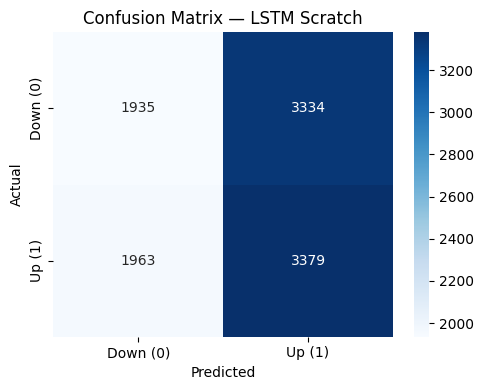

  ✔ Figure saved → /Users/mihiniboteju/cryptoflow/figures/cm_lstm_scratch.png


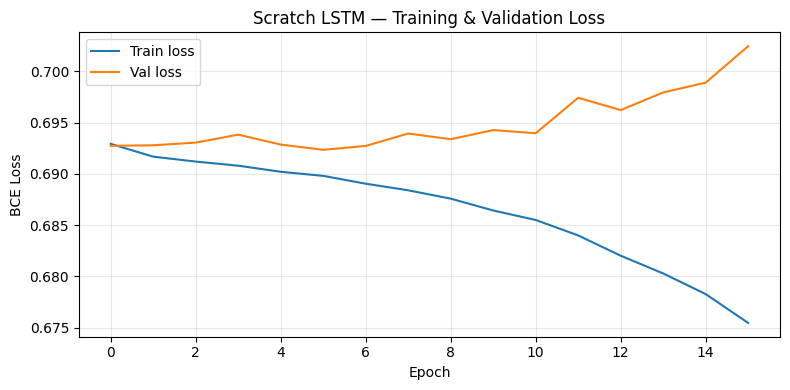

  ✔ Scratch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_scratch.pkl


In [9]:
# ── Evaluate scratch LSTM on test set ─────────────────────────────────────────
scratch_prob  = lstm_scratch.predict_proba(X_win_test)
scratch_pred  = lstm_scratch.predict(X_win_test)
scratch_metrics = compute_metrics('LSTM Scratch', y_win_test, scratch_pred, scratch_prob)

print("=== Scratch LSTM — Test Set ===")
for k, v in scratch_metrics.items():
    print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")

# Confusion matrix
plot_confusion_matrix(
    y_win_test, scratch_pred,
    model_name='LSTM Scratch',
    save_path=os.path.join(FIGURES_DIR, 'cm_lstm_scratch.png')
)

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_train_losses, label='Train loss')
ax.plot(scratch_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Scratch LSTM — Training & Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'loss_lstm_scratch.png'), dpi=120)
plt.show()

# Save scratch model
scratch_model_path = os.path.join(MODELS_DIR, 'lstm_scratch.pkl')
with open(scratch_model_path, 'wb') as f:
    pickle.dump(lstm_scratch, f)
print(f"  ✔ Scratch model saved → {scratch_model_path}")

## Part 2 — PyTorch LSTM

Uses `nn.LSTM(batch_first=True)`, the same hyperparameters, and an identical early-stopping loop. This gives a reference implementation to cross-check the scratch LSTM results.

In [10]:
class LSTMModel(nn.Module):
    """Single-layer LSTM → Linear(64→1) → Sigmoid for binary classification."""

    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.lstm   = nn.LSTM(input_dim, hidden_dim,
                              num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        out, _ = self.lstm(x)          # out: (batch, seq_len, hidden_dim)
        h_last = out[:, -1, :]         # last timestep: (batch, hidden_dim)
        logit  = self.linear(h_last)   # (batch, 1)
        return torch.sigmoid(logit).squeeze(1)  # (batch,)


def train_pytorch_lstm(model, X_tr, y_tr, X_val, y_val,
                       epochs, batch_size, patience, lr,
                       device='cpu'):
    """Train with Adam + BCE, early stopping on val loss."""
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    # Convert to tensors
    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32, device=device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    train_ds  = TensorDataset(X_tr_t, y_tr_t)
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_val   = np.inf
    best_state = None
    wait       = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        epoch_loss = 0.0

        for xb, yb in loader:
            optimiser.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * len(xb)

        epoch_loss /= len(X_tr)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:>3}/{epochs}  "
              f"train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}  "
              f"({elapsed:.1f}s)")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch} "
                      f"(best val_loss={best_val:.4f})")
                break

    # Restore best weights
    if best_state:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

pt_model = LSTMModel(input_dim=len(FEATURES), hidden_dim=HIDDEN, num_layers=N_LAYERS)
print("Training PyTorch LSTM …")
pt_model, pt_train_losses, pt_val_losses = train_pytorch_lstm(
    pt_model, X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE, lr=LR, device=DEVICE
)
print("Done.")

Device: cpu
Training PyTorch LSTM …
  Epoch   1/50  train_loss=0.6921  val_loss=0.6930  (5.4s)
  Epoch   2/50  train_loss=0.6913  val_loss=0.6928  (5.4s)
  Epoch   3/50  train_loss=0.6908  val_loss=0.6929  (4.6s)
  Epoch   4/50  train_loss=0.6905  val_loss=0.6929  (5.9s)
  Epoch   5/50  train_loss=0.6901  val_loss=0.6947  (4.8s)
  Epoch   6/50  train_loss=0.6899  val_loss=0.6934  (4.5s)
  Epoch   7/50  train_loss=0.6896  val_loss=0.6934  (4.7s)
  Epoch   8/50  train_loss=0.6893  val_loss=0.6925  (4.6s)
  Epoch   9/50  train_loss=0.6889  val_loss=0.6933  (4.6s)
  Epoch  10/50  train_loss=0.6883  val_loss=0.6931  (4.7s)
  Epoch  11/50  train_loss=0.6878  val_loss=0.6942  (4.5s)
  Epoch  12/50  train_loss=0.6870  val_loss=0.6942  (4.7s)
  Epoch  13/50  train_loss=0.6861  val_loss=0.6948  (4.5s)
  Epoch  14/50  train_loss=0.6851  val_loss=0.6939  (4.9s)
  Epoch  15/50  train_loss=0.6836  val_loss=0.6936  (5.0s)
  Epoch  16/50  train_loss=0.6821  val_loss=0.6946  (4.6s)
  Epoch  17/50  trai

=== PyTorch LSTM — Test Set ===
  model       : LSTM PyTorch
  accuracy    : 0.5150
  precision   : 0.5181
  recall      : 0.5243
  f1          : 0.5212
  roc_auc     : 0.5190


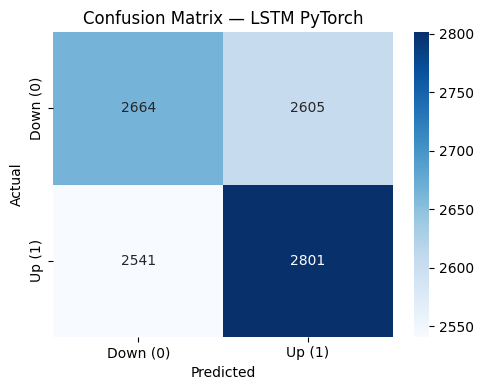

  ✔ Figure saved → /Users/mihiniboteju/cryptoflow/figures/cm_lstm_pytorch.png


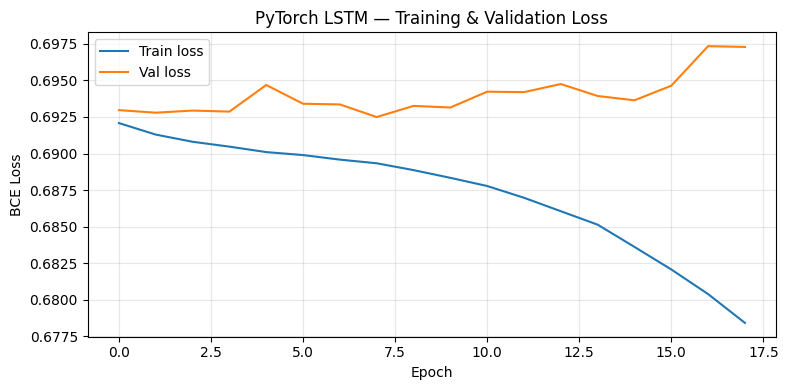

  ✔ PyTorch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_pytorch.pth


In [ ]:
# ── Evaluate PyTorch LSTM on test set ─────────────────────────────────────────
pt_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_win_test, dtype=torch.float32, device=DEVICE)
    pt_prob   = pt_model(X_test_t).cpu().numpy()

pt_pred = (pt_prob >= 0.5).astype(int)
pt_metrics = compute_metrics('LSTM PyTorch', y_win_test, pt_pred, pt_prob)

print("=== PyTorch LSTM — Test Set ===")
for k, v in pt_metrics.items():
    print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")

# Confusion matrix
plot_confusion_matrix(
    y_win_test, pt_pred,
    model_name='LSTM PyTorch',
    save_path=os.path.join(FIGURES_DIR, 'cm_lstm_pytorch.png')
)

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pt_train_losses, label='Train loss')
ax.plot(pt_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('PyTorch LSTM — Training & Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'loss_lstm_pytorch.png'), dpi=120)
plt.show()

# Save PyTorch model
pt_model_path = os.path.join(MODELS_DIR, 'lstm_pytorch.pkl')
torch.save(pt_model.state_dict(), pt_model_path)
print(f"  ✔ PyTorch model saved → {pt_model_path}")


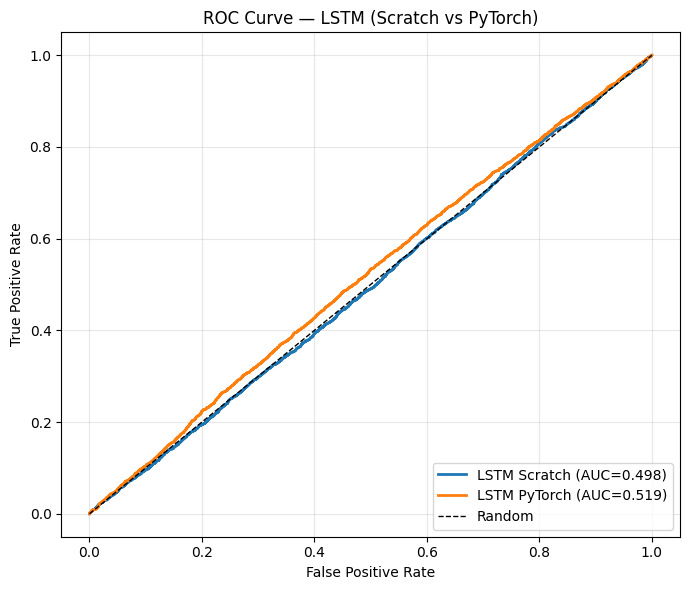

  ✔ ROC figure saved → /Users/mihiniboteju/cryptoflow/figures/roc_lstm_comparison.png
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

=== Full Classification Results ===
                                  model  accuracy  precision  sensitivity  specificity    tnr     f1  roc_auc        tp        tn        fp        fn  recall
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.0000 0.6697   0.5000 5354.0000    0.0000 5281.0000    0.0000     NaN
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5137 0.5300   0.5388 2856.0000 2713.0000 2568.0000 2498.0000     NaN
          Logistic Regression (sklearn)    0.5247     0.5275       0.5347       0.5145 0.5145 0.5311   0.5386 2863.0000 2717.0000 2564.0000 2491.0000     NaN
                Decision Tree (Scratch)    0.5296     0.5327       0.5334

In [12]:
# ── ROC Curves (both models on same plot) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for label, probs in [('LSTM Scratch', scratch_prob), ('LSTM PyTorch', pt_prob)]:
    fpr, tpr, _ = roc_curve(y_win_test, probs)
    auc_val      = roc_auc_score(y_win_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — LSTM (Scratch vs PyTorch)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_lstm_comparison.png')
fig.savefig(roc_path, dpi=120)
plt.show()
print(f"  ✔ ROC figure saved → {roc_path}")

# ── Save results to CSV ────────────────────────────────────────────────────────
save_results(scratch_metrics)
save_results(pt_metrics)

# ── Print summary table ────────────────────────────────────────────────────────
results_df = pd.read_csv(RESULTS_CSV)
pd.set_option('display.float_format', '{:.4f}'.format)
print("\n=== Full Classification Results ===")
print(results_df.to_string(index=False))